importing datasets


In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load the data
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target   # 0,1,2 correspond to species

ModuleNotFoundError: No module named 'sklearn'

In [4]:
pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.6 MB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
    --------------------------------------- 0.2/8.2 MB 3.7 MB/s eta 0:00:03
   - -------------------------------------- 0.3/8.2 MB 4.3 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/8.2 MB 4.4 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/8.2 MB 4.6 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.2 MB 4.2 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.2 MB 4.0 MB/s eta 0:00:02
   ----- ---------------------------------- 1.1/8.2 MB 3.8 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.2 MB 3.5 MB/s eta 0:00:02
   ------- ----------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install pandas matplotlib seaborn numpy


     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     --------------- ------------------------ 30.7/80.3 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 80.3/80.3 kB 1.5 MB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.2/9.3 MB 3.5 MB/s eta 0:00:03
   - -------------------------------------- 0.2/9.3 MB 2.9 MB/s eta 0:00:04
   - -------------------------------------- 0.2/9.3 MB 2.9 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.3 MB 1.8 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/9.3 MB 2.1 MB/s eta 0:00:05
   -- ------------------------------------- 0.7/9.3 MB 2.3 MB/s eta 0:00:04
   --- ------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install scikit-learn pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sklearn
print(sklearn.__version__)   # Should print a version number, e.g., 1.2.0

1.9.0


In [8]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris


iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target   

In [9]:
print("Shape:", df.shape)            # (150, 5) – 150 rows, 5 columns
print("\nData types:\n", df.dtypes)  # all float except target (int)
print("\nFirst 5 rows:\n", df.head())

Shape: (150, 5)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [10]:
print(df.isnull().sum())   # Iris has no missing values

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


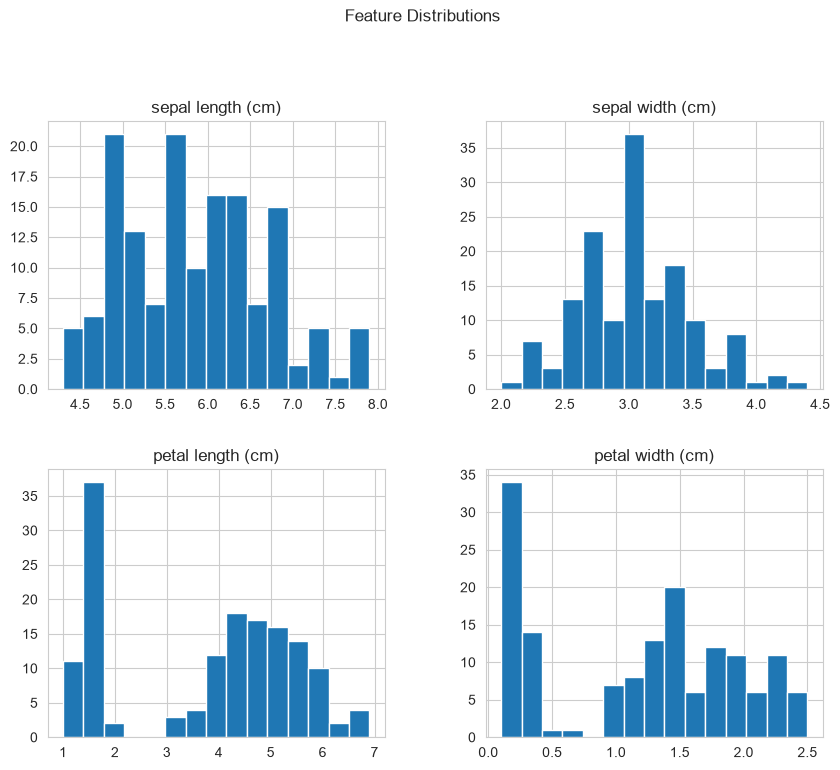

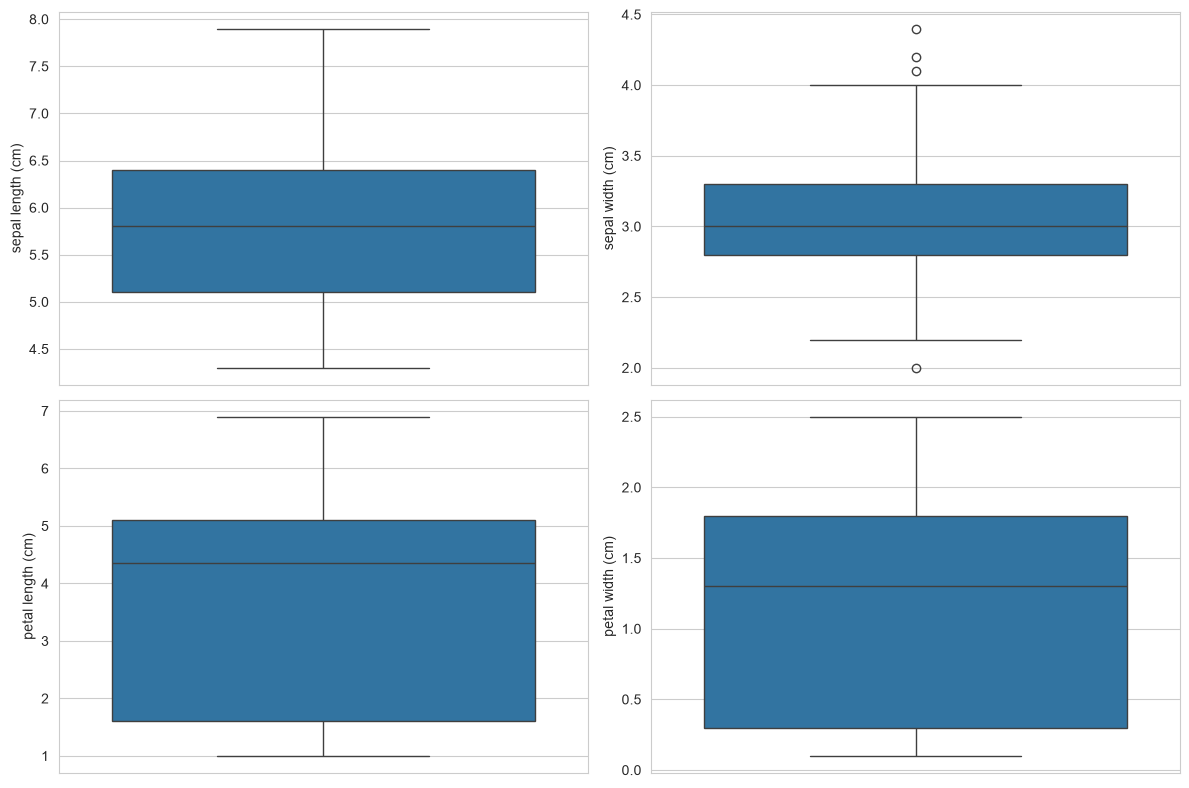

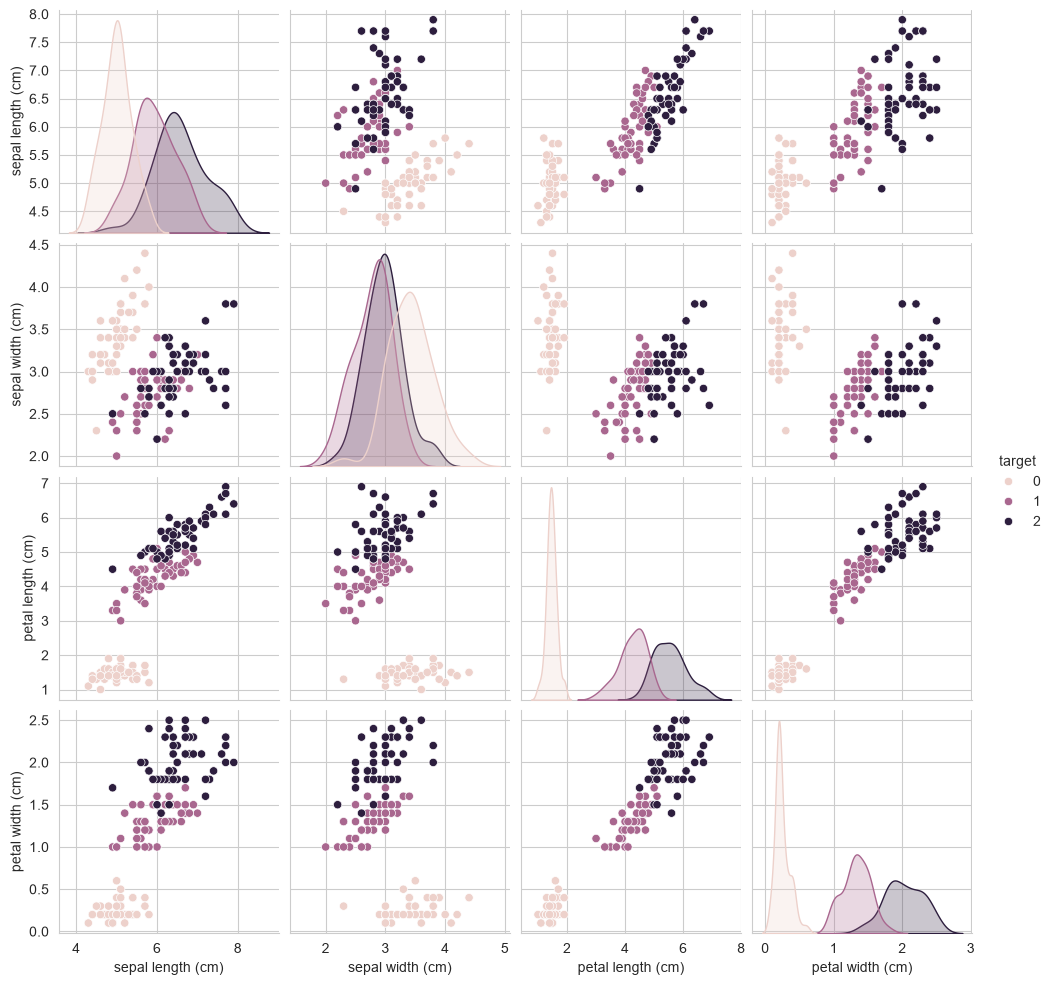

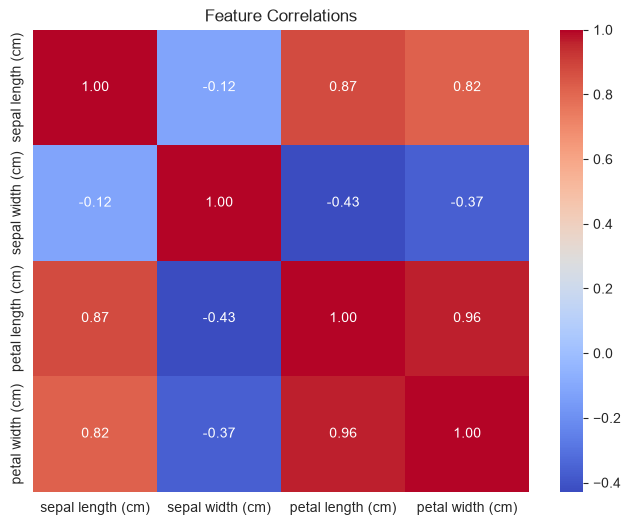

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# 1. Histograms of each feature
df.iloc[:, :4].hist(figsize=(10, 8), bins=15)
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

# 2. Boxplots to spot outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(df.columns[:4]):
    sns.boxplot(y=col, data=df, ax=axes[i//2, i%2])
plt.tight_layout()
plt.show()

# 3. Pairplot – shows relationships and class separation
sns.pairplot(df, hue='target', diag_kind='kde')
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlations")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.iloc[:, :4]   # or df.drop('target', axis=1)
y = df['target']

# First split: train (70%) and temporary (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second split: validation (half of temp = 15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 105, Val: 22, Test: 23


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train on training set
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

# Evaluate on test set (final)
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))

Validation Accuracy: 0.8636
Test Accuracy: 1.0000

Classification Report (Test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

